In [16]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

## Imports and parameters

In [ ]:
import importlib
import time

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

import balancer as bal
import estimator as est
import evaluator as evl
from alias import *
from alias import dgp
from plan import Plan

importlib.reload(evl)

## Build plan

Both BWD phi values in one plan — halves runtime vs running two separate plans.

RI evaluators registered per-phi and per-design so the null distribution always matches the design used in the real experiment. Simple randomisation gets its own RI evaluator that re-runs Simple RI

## Run simulation

Per-cell timing added so we can immediately identify any combination taking unexpectedly long (>30s/iter would be a bug signal).

In [ ]:
def make_plan():
    plan = Plan()

    # ── Designs ───────────────────────────────────────────────────────────────
    plan.add_design("Simple", bal.Simple, est.DifferenceInMeans, {})
    plan.add_design("BWD(phi=0.5)", bal.BWD, est.DifferenceInMeans, {"phi": 0.5})
    plan.add_design("BWD(phi=1.0)", bal.BWD, est.DifferenceInMeans, {"phi": 1.0})

    # ── Standard metrics ──────────────────────────────────────────────────────
    plan.add_evaluator("ATEError", evl.ATEError)
    plan.add_evaluator("CovariateMSE", evl.CovariateMSE)
    plan.add_evaluator("CISize", evl.CISize)

    # ── Neyman inference ──────────────────────────────────────────────────────
    plan.add_evaluator("NeymanCoverage", evl.ATECovers)
    plan.add_evaluator("NeymanRejects", evl.NeymanRejects, {"alpha": ALPHA})

    # RI for BWD designs — one evaluator per phi
    # Null distribution re-runs BWD with the same phi as the real experiment
    for phi in [0.5, 1.0]:
        bwd_kwargs = {"phi": phi, "delta": 0.05}
        base_ri = {"balancer_class": bal.BWD, "balancer_kwargs": bwd_kwargs, "B": B}
        phi_str = str(phi)
        plan.add_evaluator(
            f"RI_PValue_phi{phi_str}",
            evl.RandomisationInferencePValue,
            base_ri,
        )
        plan.add_evaluator(
            f"RI_Rejects_phi{phi_str}",
            evl.RandomisationInferenceRejects,
            {**base_ri, "alpha": ALPHA},
        )

    # ── RI for Simple — re-runs Simple randomisation
    # Simple RI uses the correct null distribution for Simple
    simple_ri = {"balancer_class": bal.Simple, "balancer_kwargs": {}, "B": B}
    plan.add_evaluator(
        "RI_Rejects_Simple",
        evl.RandomisationInferenceRejects,
        {**simple_ri, "alpha": ALPHA},
    )
    plan.add_evaluator(
        "RI_Coverage_Simple",
        evl.RandomisationInferenceCoverage,
        {**simple_ri, "alpha": ALPHA},
    )

    return plan


plan = make_plan()
print("Plan created with designs:", list(plan.designs.keys()))
print("Evaluators:", list(plan.evaluators.keys()))

Plan created with designs: ['Simple', 'BWD(phi=0.5)', 'BWD(phi=1.0)']
Evaluators: ['ATEError', 'CovariateMSE', 'CISize', 'NeymanCoverage', 'NeymanRejects', 'RI_PValue_phi0.5', 'RI_Rejects_phi0.5', 'RI_PValue_phi1.0', 'RI_Rejects_phi1.0', 'RI_Rejects_Simple', 'RI_Coverage_Simple']


In [29]:
B = 100  # RI re-runs — increase to 500 for final results
NUM_ITERS = 100  # iterations per cell — increase to 500 for final results
ALPHA = 0.20  # targeting 80% nominal level
sample_sizes = [100, 250, 500, 1000]

In [ ]:
dgp_factory_classes = [
    (dgp.LinearFactory, {"pate": 0.1}),
    (dgp.LinearDriftFactory, {"pate": 0.1}),
    (dgp.LinearSeasonFactory, {"pate": 0.1}),
    (dgp.QuadraticFactory, {"pate": 0.1}),
    (dgp.CubicFactory, {"pate": 0.1}),
    (dgp.SinusoidalFactory, {"pate": 0.1}),
    (dgp.QuickBlockFactory, {"pate": 1.0}),
]

dfs = []

for sample_size in sample_sizes:
    print(f"\nSample size: {sample_size}", flush=True)
    for factory_class, factory_kwargs in dgp_factory_classes:
        factory = factory_class(N=sample_size, **factory_kwargs)
        dgp_name = type(factory.create_dgp()).__name__
        print(f"  DGP: {dgp_name}", flush=True)

        t0 = time.time()
        for it in tqdm(range(NUM_ITERS)):
            result = plan.execute(factory, seed=it * 1001)
            result["iteration"] = it
            result["sample_size"] = sample_size
            result["dgp"] = dgp_name
            dfs.append(result)

        elapsed = time.time() - t0
        per_iter = elapsed / NUM_ITERS
        # Flag anything over 5s/iter as potential bug
        flag = " <<< SLOW — check for bug" if per_iter > 5 else ""
        print(f"    {elapsed:.1f}s total | {per_iter:.2f}s/iter{flag}", flush=True)

results = pd.concat(dfs, ignore_index=True)
results.to_csv("../results/inference/all_dgp_results.csv.gz", index=False)
print("\nDone.")


Sample size: 100
  DGP: LinearDGP


100%|██████████| 100/100 [00:31<00:00,  3.14it/s]

    31.9s total | 0.32s/iter
  DGP: LinearDriftDGP



100%|██████████| 100/100 [00:29<00:00,  3.36it/s]

    29.8s total | 0.30s/iter
  DGP: LinearSeasonDGP


...


100%|██████████| 100/100 [04:46<00:00,  2.87s/it]

    286.5s total | 2.87s/iter
  DGP: QuickBlockDGP



100%|██████████| 100/100 [04:59<00:00,  3.00s/it]

    299.6s total | 3.00s/iter



Done.


## Summary table 

In [21]:
summary = (
    results.groupby(["dgp", "sample_size", "design", "metric"])["value"]
    .agg(
        mean="mean",
        se=lambda x: x.std() / np.sqrt(len(x)),
    )
    .reset_index()
)

key_metrics = [
    "ATEError",
    "CovariateMSE",
    "NeymanCoverage",
    "NeymanRejects",
    "RI_Rejects_phi0.5",
    "RI_Rejects_phi1.0",
    "RI_Rejects_Simple",
    "RI_Coverage_Simple",
]

table = (
    summary[summary["metric"].isin(key_metrics)]
    .pivot_table(
        index=["dgp", "sample_size", "design"],
        columns="metric",
        values="mean",
    )
    .round(3)
)

table.reset_index().to_csv(
    "../results/tables/inference_summary_all_dgps.csv", index=False
)
table

metric                                  ATEError  CovariateMSE  \
dgp           sample_size design                                 
CubicDGP      100         BWD(phi=0.5)     0.004         0.007   
                          BWD(phi=1.0)     0.026         0.003   
                          Simple           0.078         0.016   
              250         BWD(phi=0.5)    -0.025         0.002   
                          BWD(phi=1.0)     0.000         0.001   
...                                          ...           ...   
SinusoidalDGP 500         BWD(phi=1.0)    -0.002         0.000   
                          Simple           0.004         0.002   
              1000        BWD(phi=0.5)     0.006         0.000   
                          BWD(phi=1.0)    -0.002         0.000   
                          Simple          -0.017         0.001   

metric                                  NeymanCoverage  NeymanRejects  \
dgp           sample_size design                                        
CubicDGP      100         BWD(phi=0.5)            1.00           0.11   
                          BWD(phi=1.0)            1.00           0.01   
                          Simple                  0.98           0.21   
              250         BWD(phi=0.5)            1.00           0.08   
                          BWD(phi=1.0)            1.00           0.00   
...                                                ...            ...   
SinusoidalDGP 500         BWD(phi=1.0)            1.00           0.32   
                          Simple                  0.90           0.36   
              1000        BWD(phi=0.5)            1.00           0.56   
                          BWD(phi=1.0)            1.00           0.62   
                          Simple                  0.96           0.72   

metric                                  RI_Coverage_Simple  RI_Rejects_Simple  \
dgp           sample_size design                                                
CubicDGP      100         BWD(phi=0.5)                0.89               0.10   
                          BWD(phi=1.0)                0.99               0.01   
                          Simple                      0.80               0.20   
              250         BWD(phi=0.5)                0.92               0.08   
                          BWD(phi=1.0)                0.99               0.00   
...                                                    ...                ...   
SinusoidalDGP 500         BWD(phi=1.0)                0.97               0.32   
                          Simple                      0.75               0.33   
              1000        BWD(phi=0.5)                1.00               0.55   
                          BWD(phi=1.0)                1.00               0.60   
                          Simple                      0.84               0.70   

metric                                  RI_Rejects_phi0.5  RI_Rejects_phi1.0  
dgp           sample_size design                                              
CubicDGP      100         BWD(phi=0.5)               0.23               0.32  
                          BWD(phi=1.0)               0.14               0.25  
                          Simple                     0.39               0.54  
              250         BWD(phi=0.5)               0.23               0.35  
                          BWD(phi=1.0)               0.20               0.29  
...                                                   ...                ...  
SinusoidalDGP 500         BWD(phi=1.0)               0.74               0.79  
                          Simple                     0.65               0.75  
              1000        BWD(phi=0.5)               0.91               0.94  
                          BWD(phi=1.0)               0.98               1.00  
                          Simple                     0.85               0.88  

[84 rows x 8 columns]

/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


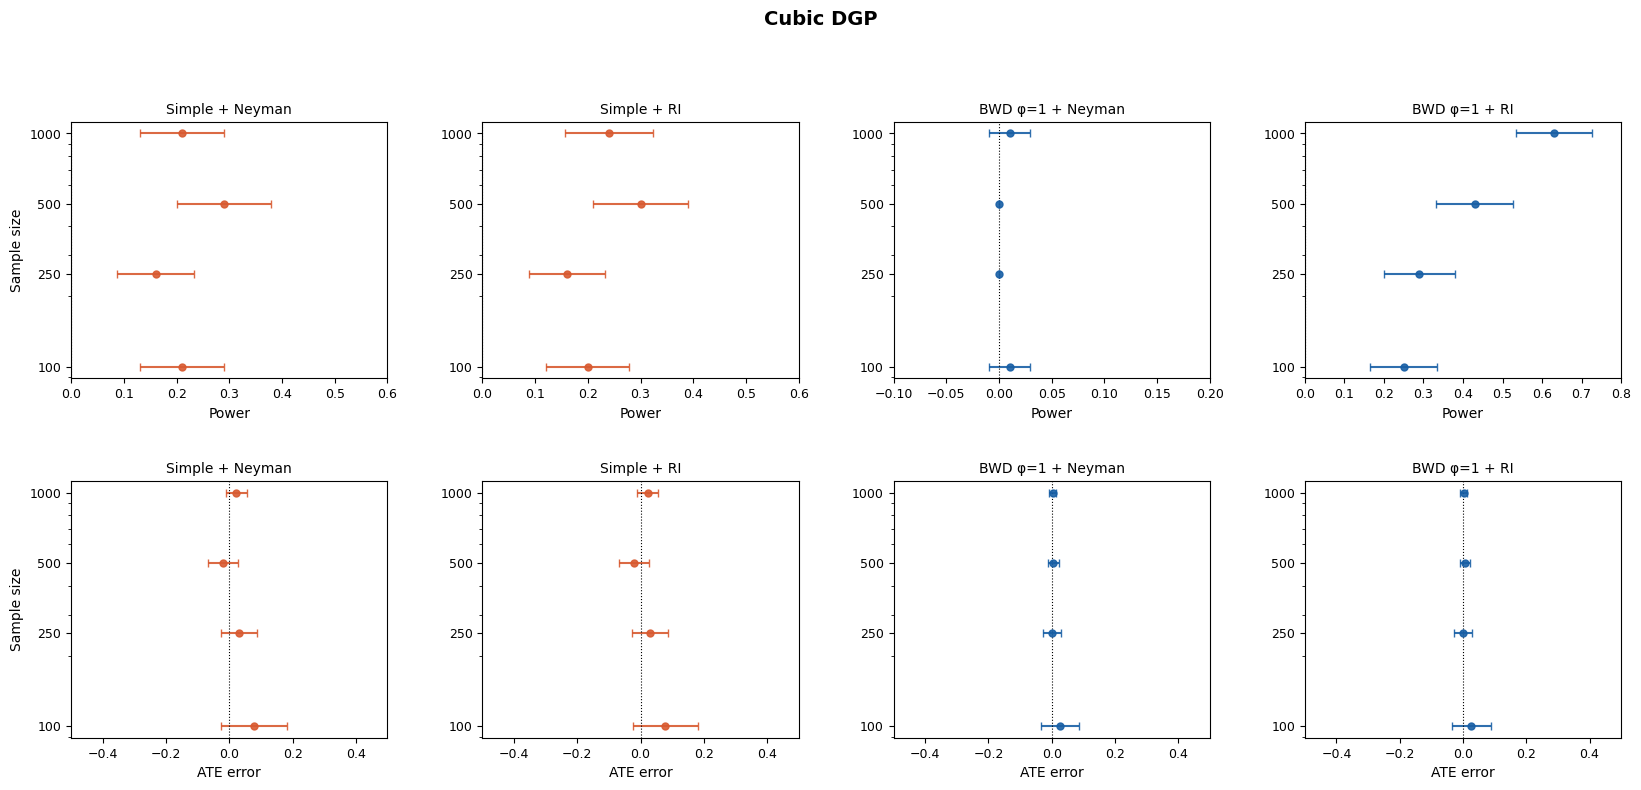

Saved: ../results/figures/CubicDGP_8panels.png


/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


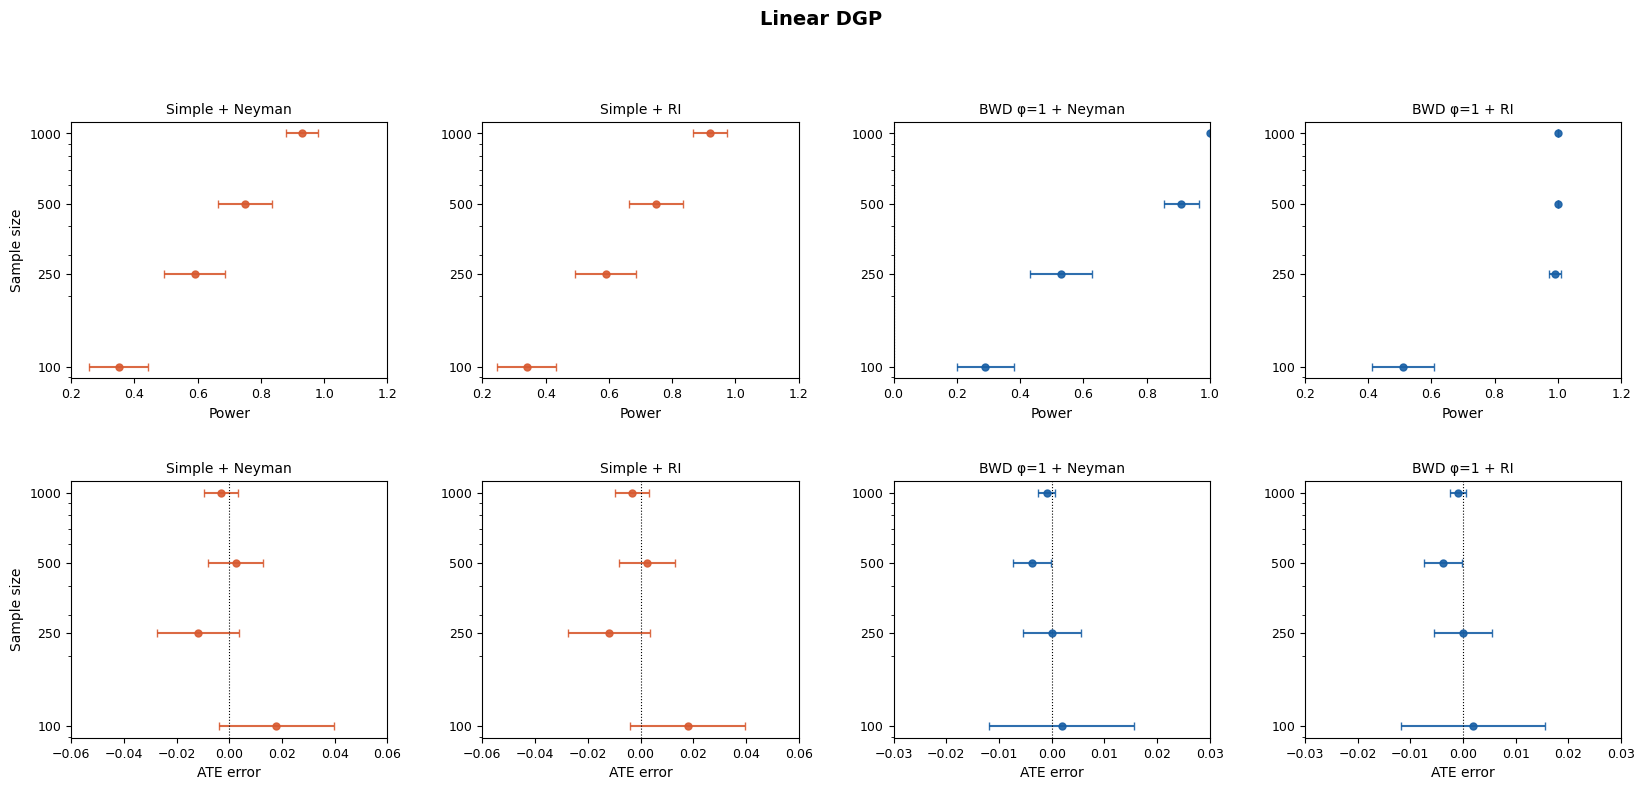

Saved: ../results/figures/LinearDGP_8panels.png


/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


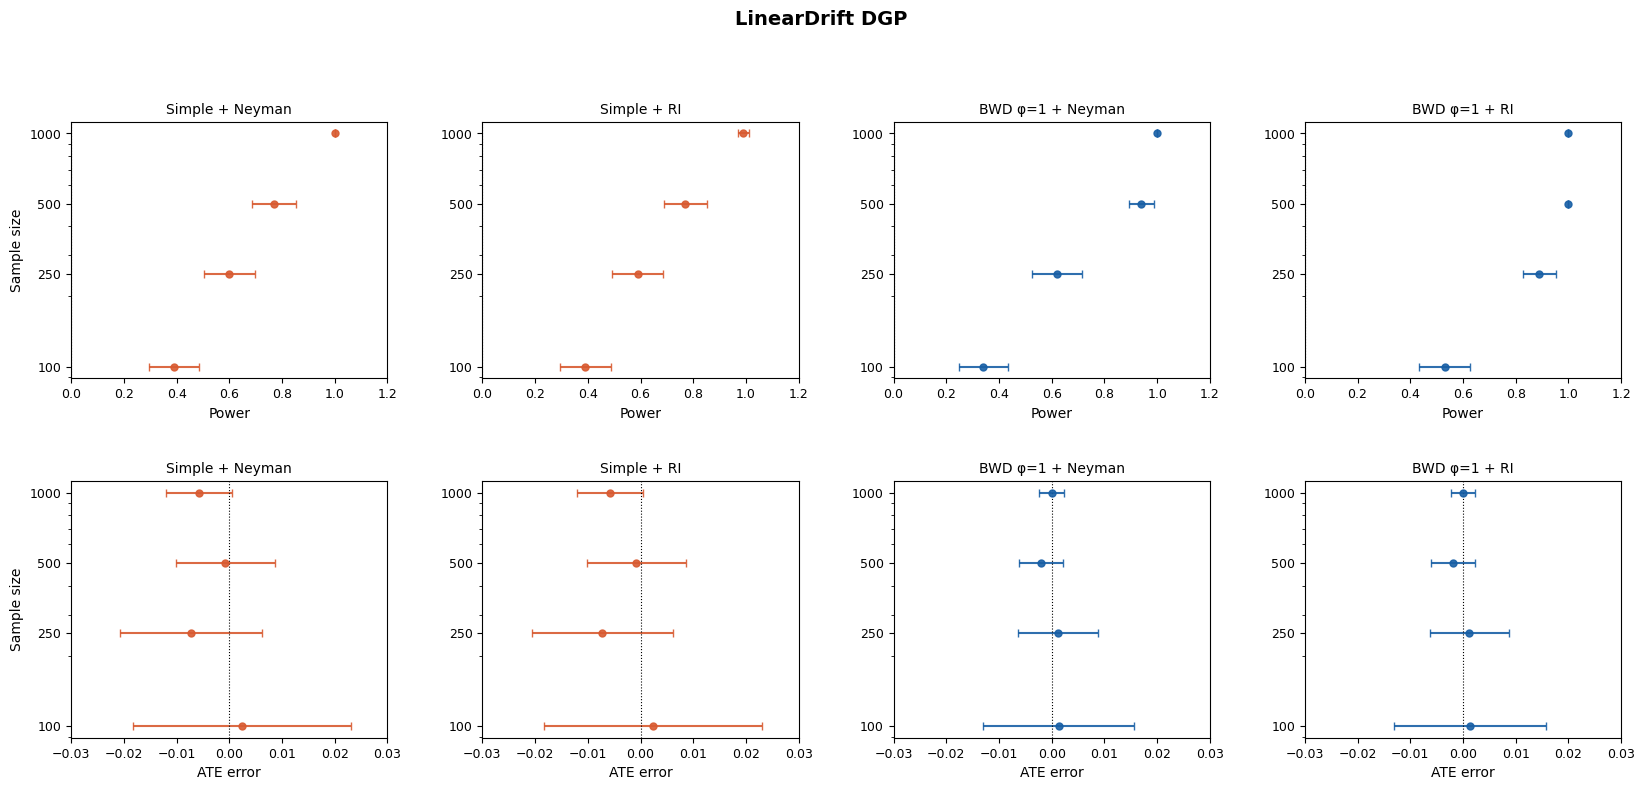

Saved: ../results/figures/LinearDriftDGP_8panels.png


/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


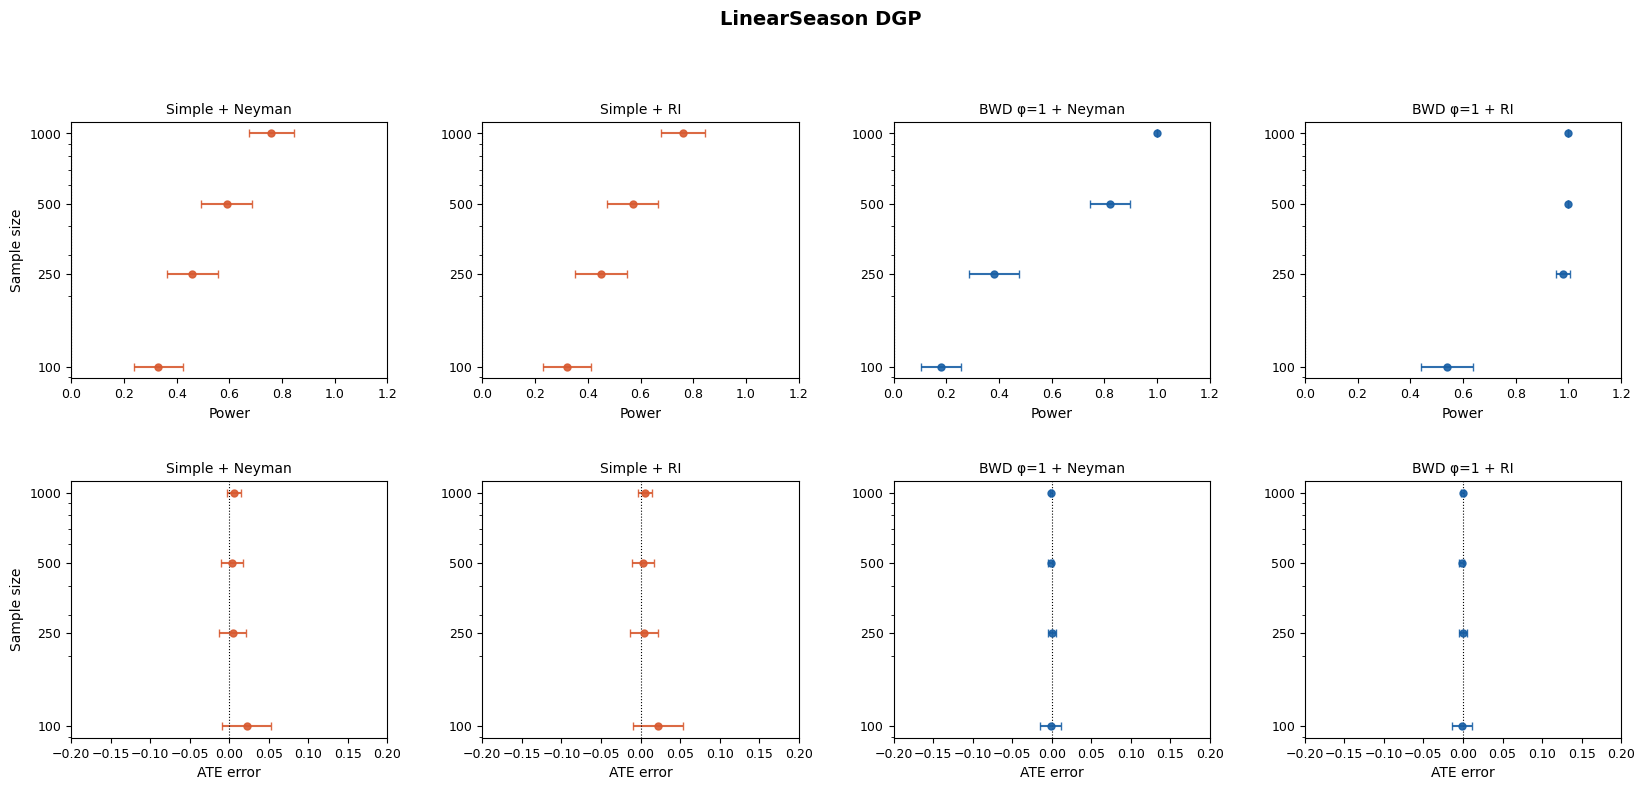

Saved: ../results/figures/LinearSeasonDGP_8panels.png


/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


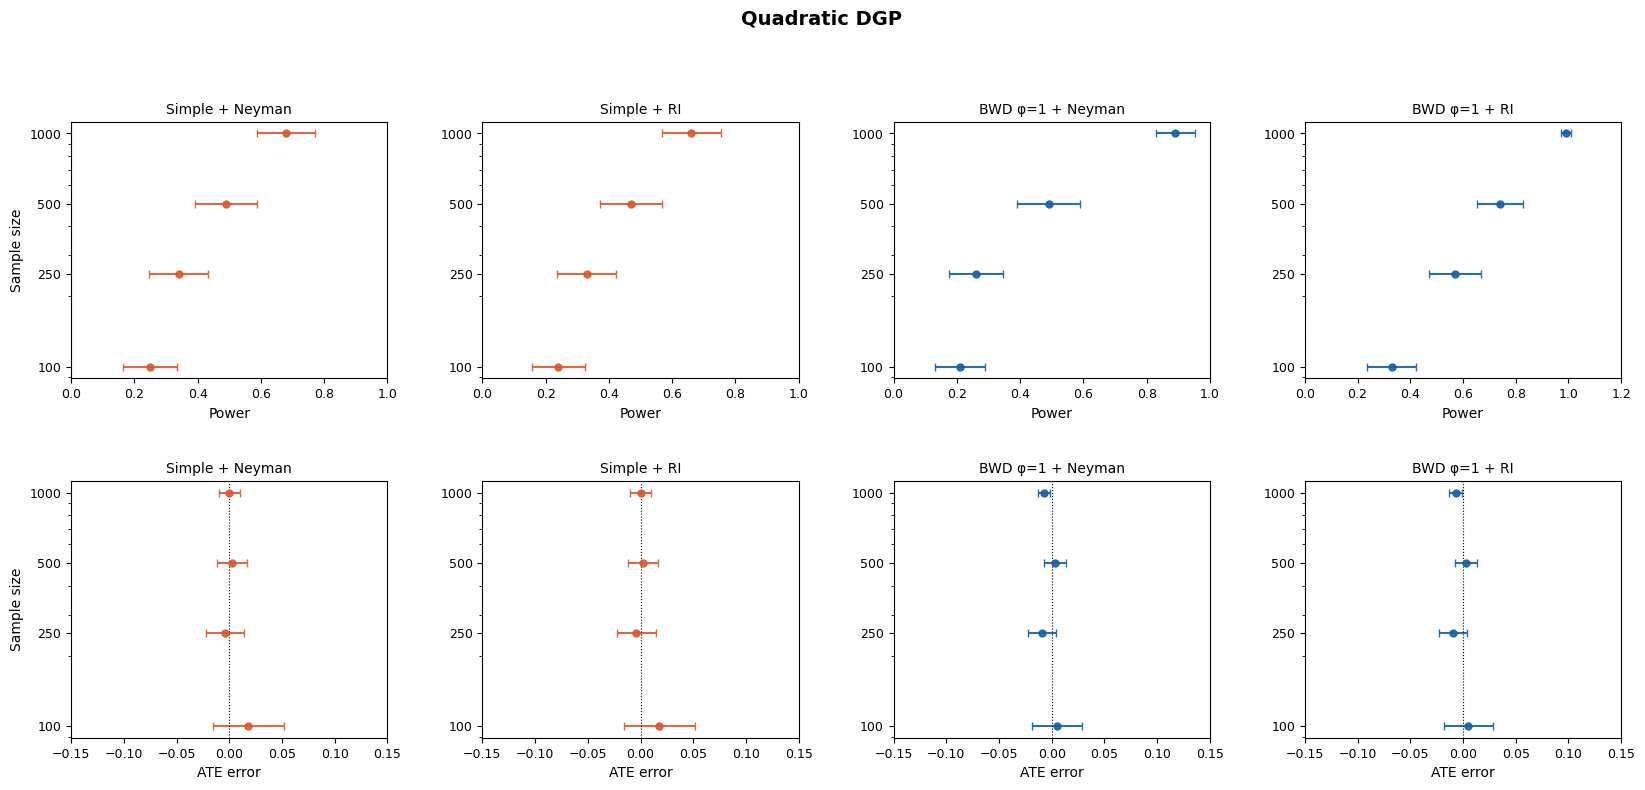

Saved: ../results/figures/QuadraticDGP_8panels.png


/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


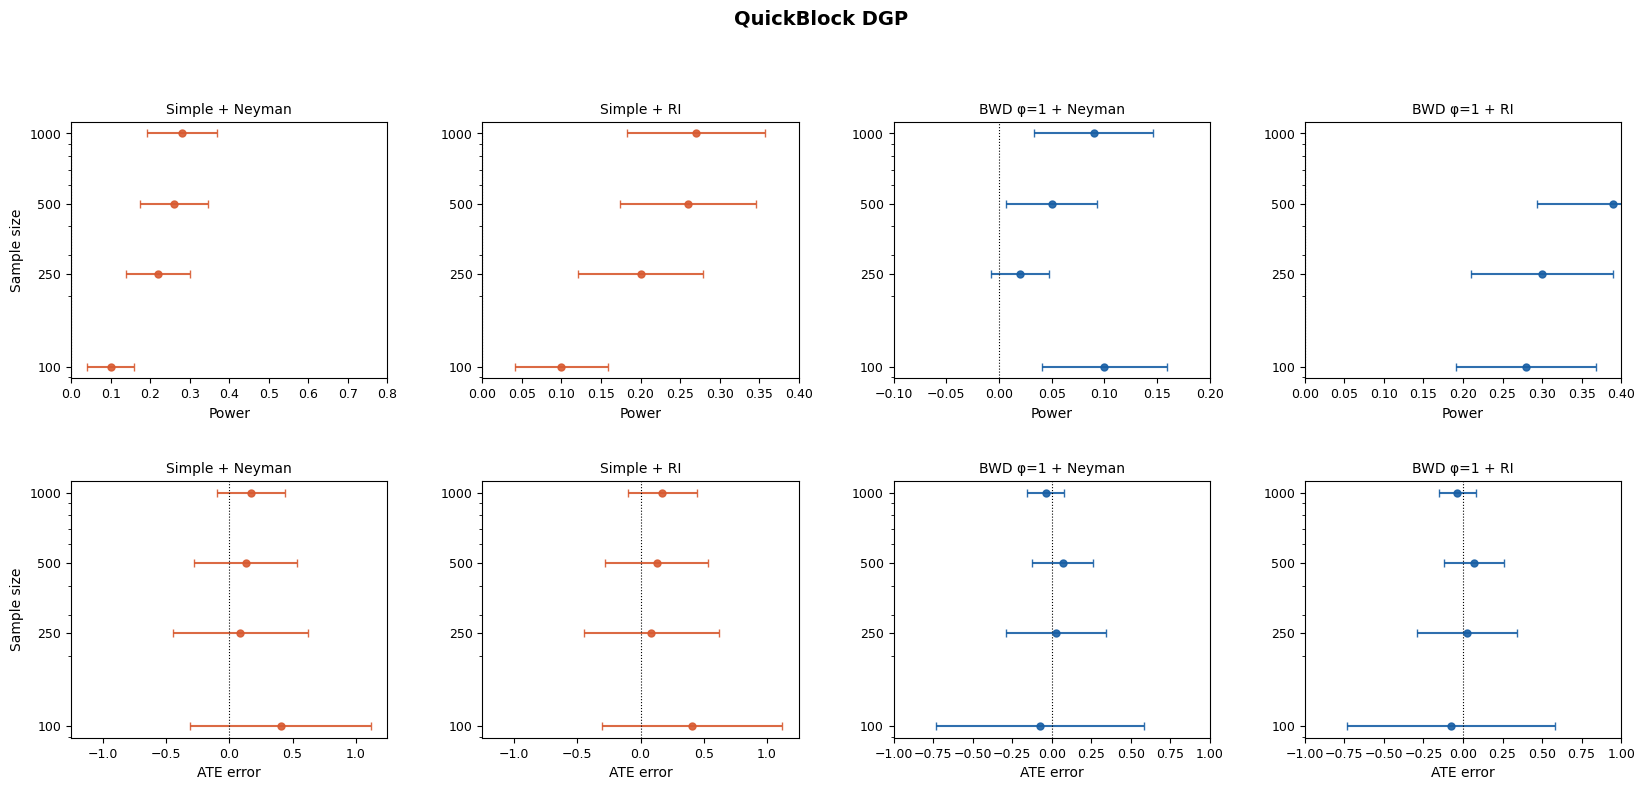

Saved: ../results/figures/QuickBlockDGP_8panels.png


/var/folders/00/bhmglhlx427341n1cdxtx73w0000gn/T/ipykernel_1480/3091075691.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


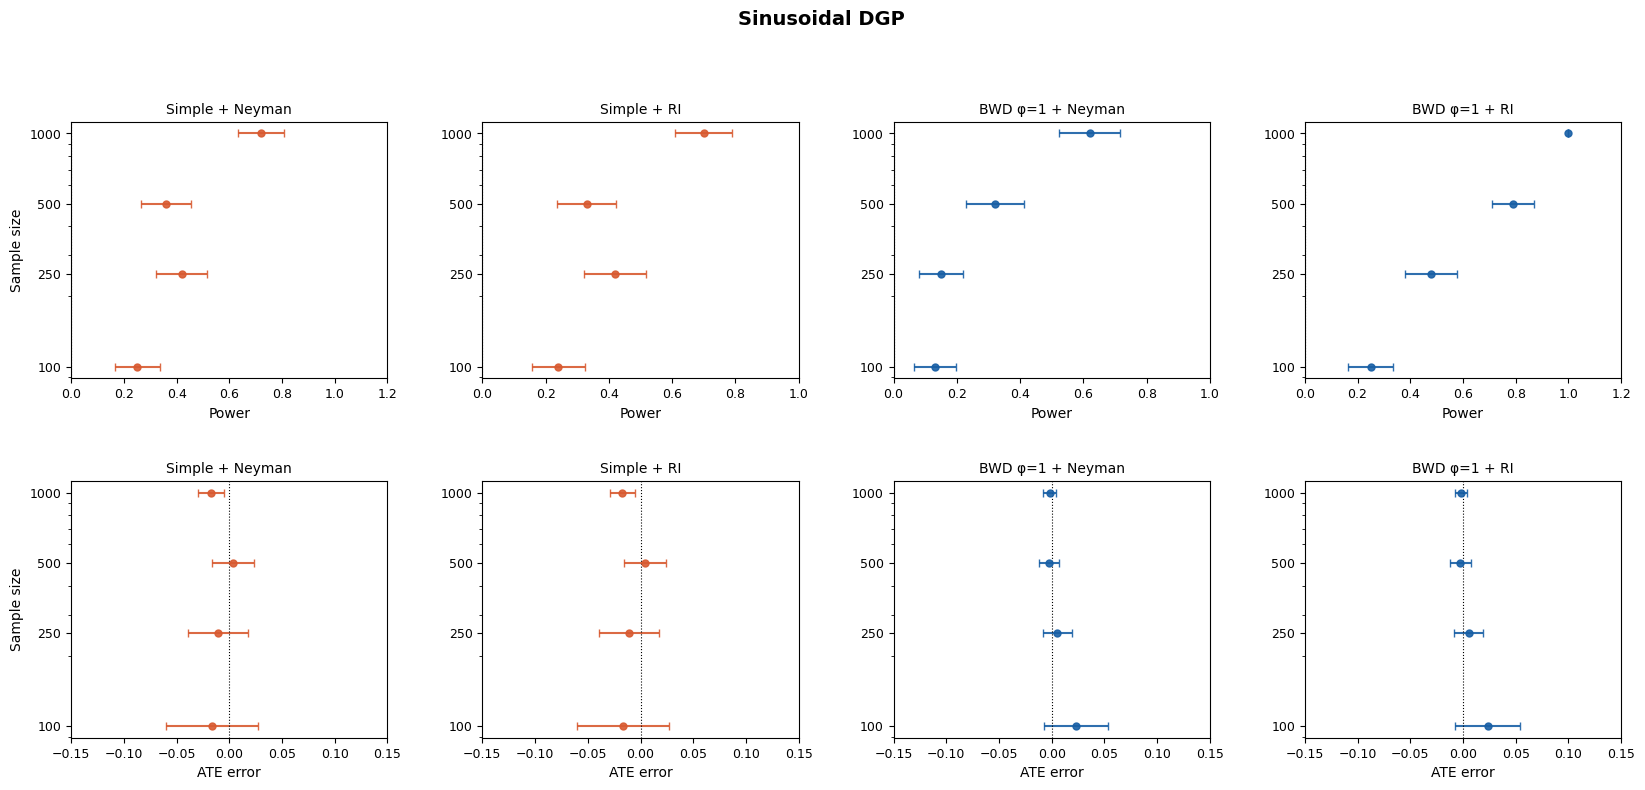

Saved: ../results/figures/SinusoidalDGP_8panels.png


In [ ]:
dgp_names = sorted(results["dgp"].unique())
DESIGNS_TO_PLOT = ["Simple", "BWD(phi=1.0)"]
TYPES = ["Neyman", "RI"]
BLUE = "#185FA5"
ORANGE = "#D85A30"
COLOR = {"Simple": ORANGE, "BWD(phi=1.0)": BLUE}

LABEL = {
    ("Simple", "Neyman"): "Simple + Neyman",
    ("Simple", "RI"): "Simple + RI",
    ("BWD(phi=1.0)", "Neyman"): "BWD φ=1 + Neyman",
    ("BWD(phi=1.0)", "RI"): "BWD φ=1 + RI",
}

y_ticks = [100, 250, 500, 1000]
# ── X-axis limits per DGP × design × type × metric ──────
xlims = {
    "linear": {
        ("Simple", "Neyman"): {"Power": (0.2, 1.2), "ATEError": (-0.06, 0.06)},
        ("Simple", "RI"): {"Power": (0.2, 1.2), "ATEError": (-0.06, 0.06)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (0, 1), "ATEError": (-0.03, 0.03)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0.2, 1.2), "ATEError": (-0.03, 0.03)},
    },
    "lineardrift": {
        ("Simple", "Neyman"): {"Power": (0, 1.2), "ATEError": (-0.03, 0.03)},
        ("Simple", "RI"): {"Power": (0, 1.2), "ATEError": (-0.03, 0.03)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (0, 1.2), "ATEError": (-0.03, 0.03)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0, 1.2), "ATEError": (-0.03, 0.03)},
    },
    "quickblock": {
        ("Simple", "Neyman"): {"Power": (0, 0.8), "ATEError": (-1.25, 1.25)},
        ("Simple", "RI"): {"Power": (0, 0.4), "ATEError": (-1.25, 1.25)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (-0.1, 0.20), "ATEError": (-1, 1)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0, 0.4), "ATEError": (-1, 1)},
    },
    "sinusoidal": {
        ("Simple", "Neyman"): {"Power": (0, 1.2), "ATEError": (-0.15, 0.15)},
        ("Simple", "RI"): {"Power": (0, 1), "ATEError": (-0.15, 0.15)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (0, 1), "ATEError": (-0.15, 0.15)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0, 1.2), "ATEError": (-0.15, 0.15)},
    },
    "cubic": {
        ("Simple", "Neyman"): {"Power": (0, 0.6), "ATEError": (-0.50, 0.50)},
        ("Simple", "RI"): {"Power": (0, 0.6), "ATEError": (-0.50, 0.50)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (-0.1, 0.2), "ATEError": (-0.50, 0.50)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0, 0.8), "ATEError": (-0.50, 0.50)},
    },
    "quadratic": {
        ("Simple", "Neyman"): {"Power": (0, 1), "ATEError": (-0.15, 0.15)},
        ("Simple", "RI"): {"Power": (0, 1), "ATEError": (-0.15, 0.15)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (0, 1), "ATEError": (-0.15, 0.15)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0, 1.2), "ATEError": (-0.15, 0.15)},
    },
    "linearseason": {
        ("Simple", "Neyman"): {"Power": (0, 1.2), "ATEError": (-0.20, 0.20)},
        ("Simple", "RI"): {"Power": (0, 1.2), "ATEError": (-0.20, 0.20)},
        ("BWD(phi=1.0)", "Neyman"): {"Power": (0, 1.2), "ATEError": (-0.20, 0.20)},
        ("BWD(phi=1.0)", "RI"): {"Power": (0, 1.2), "ATEError": (-0.20, 0.20)},
    },
}

# ── Loop over DGPs ─────────────────────────────────
for dgp_name in dgp_names:
    sub = summary[summary["dgp"] == dgp_name]

    # Clean DGP name to match keys
    dgp_key = dgp_name.lower().replace("dgp", "").strip()

    fig = plt.figure(figsize=(20, 8))
    fig.suptitle(
        f"{dgp_name.replace('DGP', '')} DGP", fontsize=14, fontweight="bold", y=1.02
    )

    gs = gridspec.GridSpec(2, 4, hspace=0.4, wspace=0.3, figure=fig)

    for row_idx, metric in enumerate(["Power", "ATEError"]):
        for col_idx, (design, type_) in enumerate(
            [(d, t) for d in DESIGNS_TO_PLOT for t in TYPES]
        ):
            ax = fig.add_subplot(gs[row_idx, col_idx])

            # Metric selection
            if metric == "Power":
                metric_name = (
                    "NeymanRejects"
                    if type_ == "Neyman"
                    else (
                        "RI_Rejects_Simple"
                        if design == "Simple"
                        else "RI_Rejects_phi1.0"
                    )
                )
            else:
                metric_name = "ATEError"

            d = sub[(sub["metric"] == metric_name) & (sub["design"] == design)]
            if d.empty:
                continue

            # Plot
            ax.errorbar(
                d["mean"],
                d["sample_size"],
                xerr=1.96 * d["se"],
                color=COLOR[design],
                linestyle="none",
                marker="o",
                markersize=5,
                capsize=3,
                alpha=0.9,
            )

            # ── ONLY vertical line at zero ───────────────
            ax.axvline(0, color="black", linestyle=":", linewidth=0.8)

            # ── X-axis control ──────────────────────────
            lims = xlims.get(dgp_key, {}).get((design, type_), {}).get(metric, None)
            if lims is not None:
                ax.set_xlim(lims)
            else:
                ax.set_xlim((-0.02, 1.05) if metric == "Power" else (-0.05, 0.05))

            # Labels
            ax.set_title(LABEL[(design, type_)], fontsize=10)
            ax.set_xlabel("Power" if metric == "Power" else "ATE error", fontsize=10)
            ax.set_ylabel("Sample size" if col_idx == 0 else "", fontsize=10)

            # ── Y-axis (log) ───────────────────────────
            ax.set_yscale("log")
            ax.set_yticks(y_ticks)
            ax.set_yticklabels([str(y) for y in y_ticks])
            ax.tick_params(labelsize=9)

    plt.tight_layout()
    fname = f"../results/figures/{dgp_name}_8panels.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")